In [12]:
from neuron import h
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Needed for 3D plots
import pyNN.neuron as sim
from pyNN.neuron import NativeCellType, simulator
from nrnutils import Mechanism, Section
from pyNN.standardmodels.cells import StandardCellType

In [7]:
################ create a cortical neuron morphology with the default valuesin the original fleming model ############
####### Create soma #########
soma = h.Section(name='soma')
soma.L = 35
soma.diam = 25  # For default cable properties

# Assign 3D coordinates to soma
soma.push()
h.pt3dclear()
h.pt3dadd(0, 55, 0, soma.diam)       # Start point (centered at origin)
h.pt3dadd(0, 20, 0, soma.diam)      # End point (extends along x-axis)
h.pop_section()

####### Create dendrite ########
dend = h.Section(name='dend')
dend.L = 20
dend.diam = 1.2

# Connect dend to soma(1)
dend.connect(soma, 1)

# Assign 3D coordinates to dendrite
dend.push()
h.pt3dclear()
h.pt3dadd(0, 20, 0, dend.diam)       # Start at end of soma
h.pt3dadd(0, 0, 0, dend.diam)      # Extend 100 μm in x direction
h.pop_section()

############## Create collateral ################
collateral = h.Section(name = "Collateral")
collateral.L = 50
collateral.diam = 0.5

# Connect collateral to dend
collateral.connect(dend, 1)

collateral.push()
h.pt3dclear()
h.pt3dadd(0, 0, 0, collateral.diam)       # Start at end of soma
h.pt3dadd(500, 0, 0, collateral.diam)      # Extend 100 μm in x direction
h.pop_section()


1.0

In [8]:
def get_3d_points(section):
    n = int(h.n3d())  # number of 3D points
    x, y, z = [], [], []
    for i in range(n):
        x.append(h.x3d(i))
        y.append(h.y3d(i))
        z.append(h.z3d(i))
    return x, y, z

In [9]:
def get_section_3d(section):
    section.push()
    x, y, z = get_3d_points(section)
    h.pop_section()
    return x, y, z

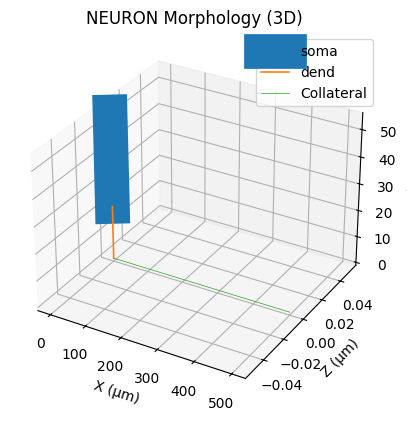

In [10]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for sec in [soma, dend, collateral]:
    x, y, z = get_section_3d(sec)
    label = str(sec)
    ax.plot(x, z, y, linewidth=sec.diam3d(0), label = label)


ax.set_xlabel('X (μm)')
ax.set_ylabel('Z (μm)')
ax.set_zlabel('Y (μm)')
ax.legend(loc = "best")
ax.set_title('NEURON Morphology (3D)')
plt.show()

In [157]:
class CorticalNeuron:
    def __init__(self):
        self.soma = h.Section(name='soma')
        self.dend = h.Section(name='dend')
        self.collateral = h.Section(name='collateral')

        self.dend.connect(self.soma(1))       # Connect dendrite to end of soma
        self.collateral.connect(self.dend(1)) # Connect collateral to end of dendrite

        self.soma.L = 35
        self.soma.diam = 25

        self.dend.L = 20
        self.dend.diam = 1.2

        self.collateral.L = 50
        self.collateral.diam = 0.5

        h.pt3dclear()
        self.soma.push()
        h.pt3dclear()
        h.pt3dadd(0, 55, 0, self.soma.diam)
        h.pt3dadd(0, 20, 0, self.soma.diam)
        h.pop_section()

        self.dend.push()
        h.pt3dclear()
        h.pt3dadd(0, 20, 0, self.dend.diam)
        h.pt3dadd(0, 0, 0, self.dend.diam)
        h.pop_section()

        self.collateral.push()
        h.pt3dclear()
        h.pt3dadd(0, 0, 0, self.collateral.diam)
        h.pt3dadd(500, 0, 0, self.collateral.diam)
        h.pop_section()

        # You can insert channel mechanisms or passive properties here
        for sec in [self.soma, self.dend, self.collateral]:
            sec.insert('pas')  # Just a placeholder, insert other mechanisms as needed
            sec.Ra = 100       # Axial resistance in ohm * cm
            sec.cm = 1         # Membrane capacitance in µF/cm^2



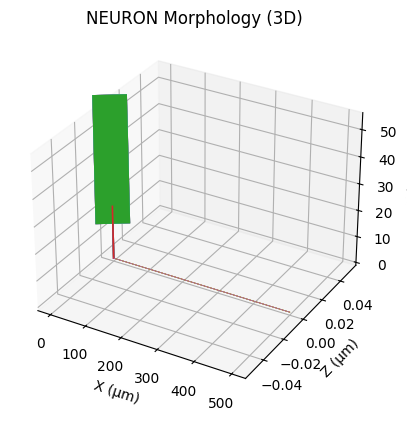

In [164]:
n_cells = 5
cells = [CorticalNeuron() for i in range(n_cells)]


fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for cell in cells:
    for sec in [cell.soma, cell.dend, cell.collateral]:
        x, y, z = get_section_3d(sec)
        label = str(sec)
        ax.plot(x, z, y, linewidth=sec.diam3d(0), label = label)


ax.set_xlabel('X (μm)')
ax.set_ylabel('Z (μm)')
ax.set_zlabel('Y (μm)')
#ax.legend(loc = "best")
ax.set_title('NEURON Morphology (3D)')
plt.show()


In [156]:
########### make a class of neurons #################
class CorticalNeuron:
    def __init__(self, L, diam):
        self.soma = h.Section(name='soma')
        #self.dend = h.Section(name='dend')
        #self.collateral = h.Section(name='collateral')

        #self.dend.connect(self.soma(1))
        #self.collateral.connect(self.dend(1))

        self.soma.L = L
        self.soma.diam = diam

        #self.dend.L = 20
        #self.dend.diam = 1.2

       # self.collateral.L = 50
        #self.collateral.diam = 0.5

        self.soma.push()
        h.pt3dclear()
        h.pt3dadd(0, 0, 0, self.soma.diam)
        h.pt3dadd(1, 2, 3, self.soma.diam)
        h.pop_section()

        #self.dend.push()
        #h.pt3dclear()
        #h.pt3dadd(0, 0, 0, self.dend.diam)
        #h.pt3dadd(0, 0, 0, self.dend.diam)
        #h.pop_section()

        #self.collateral.push()
        #h.pt3dclear()
        #h.pt3dadd(0, 0, 0, self.collateral.diam)
        #h.pt3dadd(0, 0, 0, self.collateral.diam)
        #h.pop_section()

        for sec in [self.soma]:#, self.dend, self.collateral]:
            sec.insert('hh')
            sec.Ra = 100
            sec.cm = 1
        
        self.source_section = self.soma
        self.source = self.soma(0.5)._ref_v
        self.traces = {}
        self.recording_time = False

        def memb_init(self):
            for seg in self.soma:
                seg.v = self.v_init


In [155]:
########### this doesn't fully work and I don't know why ################

class CorticalNeuronType(NativeCellType):
    default_parameters = {'L': 35, 'diam': 25}
    #default_initial_values = {'v': -65.0}
    recordable = ['soma(0.5).v']
    model = CorticalNeuron

# Setup PyNN
setup()

# Instantiate your custom cell type
cell_type = CorticalNeuronType(L=35, diam=25)

# Create population
population = Population(10, cell_type)

'''

# Record voltage and spikes
#population.record(['v'])

# Run
#p1.initialize(v=-65)
#p1.inject(sim.DCSource(amplitude=0.5, start=10, stop=90))  # optional stim
sim.run(100.0)

# Get data
data = p1.get_data().segments[0]
vm = data.filter(name='v')[0]
spikes = data.spiketrains
'''
sim.end()

#note regardless of what positions you give in the neuron class the PyNN seems to override this and put them where it wants

print(population.positions[0])
print(population.positions[1])
print(population.positions[2])


[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
